<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 77 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">t-Tests 📏</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">Real samples are modest and sigma is unknown, exactly where Student's t shines. We build the one-sample, two-sample (Welch), and paired t-tests, see why pairing is so powerful, then answer three questions about a flipped-classroom study with the right test for each.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(77)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · THE ONE-SAMPLE t-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Test a mean when sigma is unknown</div>
<div style="color:#4a5578;margin-top:6px">When the population sigma is unknown (almost always) we estimate it with the sample sd s and compare to Student's t with n-1 degrees of freedom. The statistic is t = (xbar - mu0)/(s/sqrt(n)).</div>
</div>

In [2]:
x = rng.normal(52, 9, 25)
res = stats.ttest_1samp(x, 50)
n=len(x); t=(x.mean()-50)/(x.std(ddof=1)/np.sqrt(n))
print(f"n={n}, mean={x.mean():.2f}, sd={x.std(ddof=1):.2f}")
print(f"t (by hand) = {t:.3f}, df={n-1}")
print(f"scipy: t={res.statistic:.3f}, two-sided p={res.pvalue:.4f}")

n=25, mean=49.87, sd=10.82
t (by hand) = -0.059, df=24
scipy: t=-0.059, two-sided p=0.9538


This is the test we met in Chapter 74. With a modest sample and unknown sigma, the t distribution&#39;s heavier tails give the honest, slightly wider, accounting of uncertainty that the normal curve would understate.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE TWO-SAMPLE t-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Comparing two independent groups</div>
<div style="color:#4a5578;margin-top:6px">To compare the means of two independent groups we test H0: muA = muB. By default use WELCH'S t-test, which does NOT assume equal variances; it is safer than the classic pooled test and rarely wrong. scipy: equal_var=False.</div>
</div>

In [3]:
a = rng.normal(50, 8, 60)   # group A
b = rng.normal(55, 12, 70)  # group B (different mean AND spread)
welch = stats.ttest_ind(a, b, equal_var=False)
pooled = stats.ttest_ind(a, b, equal_var=True)
print(f"meanA={a.mean():.2f}, meanB={b.mean():.2f}, difference={b.mean()-a.mean():+.2f}")
print(f"Welch  t={welch.statistic:.3f}, p={welch.pvalue:.4f}  (default, unequal variances OK)")
print(f"pooled t={pooled.statistic:.3f}, p={pooled.pvalue:.4f}  (assumes equal variances)")

meanA=50.93, meanB=53.24, difference=+2.31
Welch  t=-1.359, p=0.1767  (default, unequal variances OK)
pooled t=-1.309, p=0.1930  (assumes equal variances)


Welch&#39;s test adjusts the degrees of freedom for unequal spreads, so it stays valid when the two groups have different variances, the common case. Reach for the pooled version only when you have a real reason to believe the variances match.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · THE PAIRED t-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When each observation has a partner</div>
<div style="color:#4a5578;margin-top:6px">If the two measurements are PAIRED, before/after on the same subject, left/right, matched cases, do NOT treat them as independent. Form each pair's difference and run a ONE-sample t-test on the differences. Pairing removes between-subject noise, so it is far more powerful.</div>
</div>

In [4]:
before = rng.normal(140, 16, 40)
after  = before - rng.normal(6, 7, 40)   # a real within-subject drop
paired = stats.ttest_rel(after, before)
wrong  = stats.ttest_ind(after, before, equal_var=False)  # ignoring the pairing
d = after - before
print(f"mean difference (after - before) = {d.mean():+.2f}")
print(f"PAIRED t-test:      t={paired.statistic:.2f}, p={paired.pvalue:.2e}  (correct)")
print(f"unpaired (WRONG):   t={wrong.statistic:.2f}, p={wrong.pvalue:.3f}  (throws away the pairing)")

mean difference (after - before) = -4.85
PAIRED t-test:      t=-4.67, p=3.52e-05  (correct)
unpaired (WRONG):   t=-1.24, p=0.219  (throws away the pairing)


Same data, very different verdicts: the paired test sees the consistent within-person drop and is decisive, while wrongly treating the columns as independent buries that signal in between-person variation. Match the test to the design, paired data needs a paired test.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · DID THE FLIPPED CLASSROOM WORK?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Three t-tests on one class dataset</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A school tested two teaching methods and recorded each student&#39;s <strong>pre</strong> and <strong>post</strong> scores (`ch77_class_scores.xlsx`). We ask three questions, each a different t-test: did students improve (paired), did the flipped method beat traditional (two-sample), and did the average gain exceed a 5-point target (one-sample)?

In [5]:
try:    sc = pd.read_excel("../../data/ch77_class_scores.xlsx", sheet_name="Scores")
except FileNotFoundError: sc = pd.read_excel(BASE+"ch77_class_scores.xlsx", sheet_name="Scores")
print("loaded:", sc.shape)
gain = sc.posttest - sc.pretest
paired = stats.ttest_rel(sc.posttest, sc.pretest)
print(f"[PAIRED] mean gain = {gain.mean():.2f} pts, t={paired.statistic:.2f}, p={paired.pvalue:.2e} -> students improved")

loaded: (120, 4)
[PAIRED] mean gain = 8.03 pts, t=15.78, p=6.00e-31 -> students improved


[TWO-SAMPLE] flipped 74.22 vs traditional 65.61 on posttest
             Welch t=4.41, p=2.33e-05 -> flipped is better
[ONE-SAMPLE] mean gain vs target 5: t=5.95, p=2.71e-08 -> gain exceeds 5


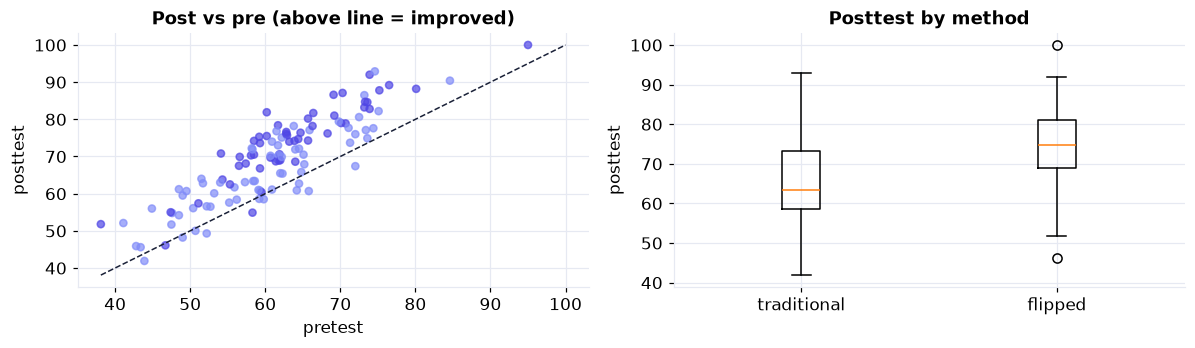

In [6]:
fl = sc[sc.method=="flipped"].posttest; tr = sc[sc.method=="traditional"].posttest
two = stats.ttest_ind(fl, tr, equal_var=False)
print(f"[TWO-SAMPLE] flipped {fl.mean():.2f} vs traditional {tr.mean():.2f} on posttest")
print(f"             Welch t={two.statistic:.2f}, p={two.pvalue:.2e} -> flipped is better")
one = stats.ttest_1samp(gain, 5)
print(f"[ONE-SAMPLE] mean gain vs target 5: t={one.statistic:.2f}, p={one.pvalue:.2e} -> gain exceeds 5")
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].scatter(sc.pretest, sc.posttest, c=(sc.method=="flipped").map({True:IND,False:LIGHT}), alpha=0.7, s=22)
lims=[sc.pretest.min(),sc.posttest.max()]; ax[0].plot(lims,lims,color=INK,ls="--",lw=1)
ax[0].set_xlabel("pretest"); ax[0].set_ylabel("posttest"); ax[0].set_title("Post vs pre (above line = improved)")
ax[1].boxplot([tr,fl], tick_labels=["traditional","flipped"]); ax[1].set_ylabel("posttest")
ax[1].set_title("Posttest by method"); plt.tight_layout(); plt.show()

All three tests are decisive. Students improved by about <strong>8 points</strong> on average (paired t = 15.8, p tiny); the flipped method scored higher on the posttest (74.2 vs 65.6, Welch t = 4.41, p &#8776; 0.00002); and the average gain comfortably beat the 5-point target (one-sample t = 5.95). The lesson is choosing the right t-test for each question: one design, three tests.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ t-tests</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">The t-test handles an unknown sigma via Student&#39;s t with n-1 df. One-sample tests a mean against a value; the two-sample (Welch by default) compares two independent groups; the paired test analyzes within-pair differences and is far more powerful when the design is paired. On real class data, students gained ~8 points (paired), the flipped method won (two-sample, p&#8776;0.00002), and the gain beat a 5-point target. Next: ANOVA, the t-test extended to three or more groups.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>